# Flare Distribution Model — corrected

This notebook is a cleaned and corrected version of the original flare-distribution notebook.

The main correction is that the **planet-induced percentage (PIP)** is treated as a true fraction of the total flare population.  
For example, if `PIP = 0.05`, then only 5% of all flares are drawn from the planet-induced component. The remaining 95% are drawn from the intrinsic stellar component.

This is different from interpreting PIP as a peak amplitude. A small PIP can still look visually large if every curve is normalised by its own maximum, so the plots below use a global normalisation when the amplitudes need to be compared.


In [1]:
# --- Standard Library ---
import os
import math
import time

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from tqdm import tqdm

# Reproducible random numbers
rng = np.random.default_rng(42)

# --- Global Settings ---
np.set_printoptions(suppress=True, precision=6)
from matplotlib import rcParams, font_manager as fm
# --- Load custom font --- 
custom_font = fm.FontProperties(
    fname="/usr/share/fonts/dejavu-serif-fonts/DejaVuSerifCondensed.ttf"
)

# --- Apply global Matplotlib settings --- 
plt.rcParams.update({
    "font.family": custom_font.get_name(),
    "mathtext.fontset": "stix",
    "font.size": 16,
    "figure.dpi": 300
})

os.makedirs("figures", exist_ok=True)


## Main functions

The model is made from two parts:

1. an intrinsic stellar component, which is uniform over orbital phase;
2. a planet-induced component, which is concentrated inside the SPI phase region.

The two components are mixed as

\[
p_{\rm total}(\phi) = (1-\mathrm{PIP}) p_{\rm intrinsic}(\phi)
+ \mathrm{PIP}\, p_{\rm planet}(\phi).
\]

This means that PIP is the actual fraction of the full flare population that belongs to the planet-induced component.


In [2]:
def phase_grid(n_bins=100):
    """
    Create the phase grid used throughout the notebook.

    The grid follows the original notebook convention:
    phase = [-0.5, -0.48, ..., 0.48].

    With 50 bins, the interval [-0.25, 0.25] contains exactly half
    of the phase grid. This is important for the PIP estimate:
    n_PIP = n_in - n_out.
    """
    phase = np.arange(-0.5, 0.5, 1 / n_bins)
    dphi = 1 / n_bins

    assert len(phase) == n_bins
    assert np.isclose(dphi, phase[1] - phase[0])
    return phase, dphi


def planet_phase_kernel(phase, slope=-2, spi_width=0.25):
    """
    Return the planet-induced phase kernel.

    The kernel is only non-zero inside [-spi_width, spi_width].
    Inside that region it follows a cosine-shaped enhancement
    centred on phase zero.

    The exponent is connected to the flare-energy slope in a simple
    phenomenological way, following the original notebook logic.
    """
    phase = np.asarray(phase)
    kernel = np.zeros_like(phase, dtype=float)

    mask = (phase >= -spi_width) & (phase <= spi_width)
    eta = abs(slope + 1)

    # Avoid a fully flat planet kernel in the special limiting case.
    if eta == 0:
        eta = 1.0

    kernel[mask] = np.clip(np.cos(2 * np.pi * phase[mask]), 0, None) ** eta

    if kernel.sum() <= 0:
        raise ValueError("Planet kernel has zero total weight. Check the phase grid and SPI width.")

    kernel /= kernel.sum()
    return kernel


def flare_distribution_model(
    intrinsic_flaring_rate,
    planet_ratio,
    slope=-2,
    n_bins=100,
    spi_width=0.25,
):
    """
    Create the corrected flare-distribution model.

    Parameters
    ----------
    intrinsic_flaring_rate : float
        Mean flare rate in flares per day.
    planet_ratio : float
        Planet-induced percentage as a fraction between 0 and 1.
        This is the fraction of all flares assigned to the planet-induced
        component.
    slope : float
        Flare-energy power-law slope used to shape the planet-induced peak.
    n_bins : int
        Number of phase bins.
    spi_width : float
        Half-width of the SPI region in orbital phase.

    Returns
    -------
    model : dict
        Dictionary containing phase, intrinsic probability, planet probability,
        total probability, and flaring-rate versions of the same model.
    """
    assert intrinsic_flaring_rate > 0, "intrinsic_flaring_rate must be positive."
    assert 0 <= planet_ratio <= 1, "planet_ratio must be between 0 and 1."
    assert n_bins > 1, "n_bins must be larger than 1."

    phase, dphi = phase_grid(n_bins)

    p_intrinsic = np.ones(n_bins, dtype=float)
    p_intrinsic /= p_intrinsic.sum()

    p_planet = planet_phase_kernel(phase, slope=slope, spi_width=spi_width)

    # Corrected mixture:
    # PIP is now exactly the fraction of all flares in the planet component.
    p_total = (1 - planet_ratio) * p_intrinsic + planet_ratio * p_planet
    p_total /= p_total.sum()

    # Rate per bin sums to the intrinsic flaring rate.
    rate_per_bin = intrinsic_flaring_rate * p_total

    # Rate density integrates to the intrinsic flaring rate over phase.
    rate_density = rate_per_bin / dphi

    return {
        "phase": phase,
        "dphi": dphi,
        "p_intrinsic": p_intrinsic,
        "p_planet": p_planet,
        "p_total": p_total,
        "rate_per_bin": rate_per_bin,
        "rate_density": rate_density,
        "eta": abs(slope + 1) if abs(slope + 1) != 0 else 1.0,
        "spi_width": spi_width,
    }


def estimate_pip_from_distribution(probability, phase, spi_width=0.25):
    """
    Estimate PIP from a phase distribution using the same expression
    as in the thesis text:

        PIP = n_in - n_out,

    where the SPI region covers half of the phase space.
    For a probability distribution this becomes:

        PIP = P_in - P_out.
    """
    probability = np.asarray(probability, dtype=float)
    probability = probability / probability.sum()

    mask = (phase >= -spi_width) & (phase <= spi_width)
    p_in = probability[mask].sum()
    p_out = probability[~mask].sum()

    return p_in - p_out, p_in, p_out


def create_pdf(
    intrinsic_flaring_rate,
    planet_ratio,
    amount_of_flares,
    slope,
    E_thres=None,
    e_min=None,
    e_max=None,
    plot=False,
    n_bins=100,
    spi_width=0.25,
    rng=rng,
):
    """
    Compatibility function with the original notebook.

    The old notebook created planet and intrinsic flare samples separately,
    but the mixing step made low-PIP cases visually too strong. Here the
    mixing is corrected by forcing the planet component to contain exactly
    the requested fraction of the total flare population.

    The energy arguments are kept in the function call for compatibility
    with the original notebook. The final model is now analytic in phase,
    and the slope controls the cosine-shaped planet component.
    """
    assert amount_of_flares > 0
    assert 0 <= planet_ratio <= 1

    model = flare_distribution_model(
        intrinsic_flaring_rate=intrinsic_flaring_rate,
        planet_ratio=planet_ratio,
        slope=slope,
        n_bins=n_bins,
        spi_width=spi_width,
    )

    phase = model["phase"]
    p_intrinsic = model["p_intrinsic"]
    p_planet = model["p_planet"]
    p_total = model["p_total"]

    # Draw the two populations separately so the requested PIP is explicit.
    n_planet = int(round(amount_of_flares * planet_ratio))
    n_intrinsic = amount_of_flares - n_planet

    intrinsic_bins = rng.choice(n_bins, size=n_intrinsic, p=p_intrinsic)
    planet_bins = rng.choice(n_bins, size=n_planet, p=p_planet)

    counts_intrinsic = np.bincount(intrinsic_bins, minlength=n_bins)
    counts_planet = np.bincount(planet_bins, minlength=n_bins)
    counts = counts_intrinsic + counts_planet

    # Expected counts according to the corrected model.
    final_fit = amount_of_flares * p_total

    # This is the probability distribution used for sampling fake flare times.
    normalized_final_fit = p_total

    if plot:
        fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

        expected_planet = amount_of_flares * planet_ratio * p_planet
        expected_intrinsic = amount_of_flares * (1 - planet_ratio) * p_intrinsic

        ax[0].plot(phase, counts_planet, color="#003366", lw=2, label="Simulated data")
        ax[0].plot(phase, expected_planet, color="crimson", lw=2, ls="--",
                   label=rf"Cos$^{{{model['eta']:.1f}}}$ model")
        ax[0].axvspan(-spi_width, spi_width, color="forestgreen", alpha=0.15, zorder=1)
        ax[0].set_xlim(-0.5, 0.5)
        ax[0].set_ylim(0)
        ax[0].set_xlabel(r"Orbital phase, $\phi$")
        ax[0].set_ylabel("Frequency")
        ax[0].set_title("Planet-induced flaring", weight="bold")
        ax[0].legend(loc="upper left")

        ax[1].plot(phase, counts_intrinsic, color="#003366", lw=2, label="Simulated data")
        ax[1].plot(phase, expected_intrinsic, color="crimson", lw=2, ls="--",
                   label="Uniform model")
        ax[1].axvspan(-spi_width, spi_width, color="forestgreen", alpha=0.15, zorder=1)
        ax[1].set_xlim(-0.5, 0.5)
        ax[1].set_ylim(0)
        ax[1].set_xlabel(r"Orbital phase, $\phi$")
        ax[1].set_ylabel("Frequency")
        ax[1].set_title("Intrinsic flaring", weight="bold")
        ax[1].legend(loc="upper left")

        ax[2].plot(phase, counts, color="#003366", lw=2, label="Simulated data")
        ax[2].plot(phase, final_fit, color="crimson", lw=2, ls="--", label="Fitted model")
        ax[2].axvspan(-spi_width, spi_width, color="forestgreen", alpha=0.15, zorder=1)
        ax[2].set_xlim(-0.5, 0.5)
        ax[2].set_ylim(0)
        ax[2].set_xlabel(r"Orbital phase, $\phi$")
        ax[2].set_ylabel("Frequency")
        ax[2].set_title("Combined flaring", weight="bold")
        ax[2].legend(loc="upper left")

        plt.tight_layout()
        plt.show()

    return counts_planet, counts_intrinsic, counts, final_fit, normalized_final_fit


def sample_points(x, probability, n_points, rng=rng):
    """
    Sample points from a discrete phase distribution.
    """
    x = np.asarray(x)
    probability = np.asarray(probability, dtype=float)
    probability = probability / probability.sum()

    return rng.choice(x, size=n_points, p=probability)


def pairwise_waiting_times(timeseries):
    """
    Compute all positive pairwise waiting times from a sequence of time points.
    """
    t = np.sort(np.asarray(timeseries, dtype=float))
    return [t[j] - t[i] for i in range(len(t)) for j in range(i + 1, len(t))]


def Fake_data(
    intrinsic_flaring_rate,
    planet_ratio,
    amount_of_flares,
    slope,
    E_thres,
    e_min,
    e_max,
    total_observing_time,
    Period,
    plot=False,
    n_bins=100,
    rng=rng,
):
    """
    Generate fake flare times using the corrected phase distribution.

    The number of flares is fixed to int(IFR * total_observing_time),
    following the original notebook. The phase distribution is repeated
    over the orbital period and truncated at the total observing time.
    """
    assert intrinsic_flaring_rate > 0
    assert 0 <= planet_ratio <= 1
    assert total_observing_time > 0
    assert Period > 0

    model = flare_distribution_model(
        intrinsic_flaring_rate=intrinsic_flaring_rate,
        planet_ratio=planet_ratio,
        slope=slope,
        n_bins=n_bins,
    )

    phase = model["phase"]
    dphi = model["dphi"]
    probability = model["p_total"]

    number_simulated_flares = int(total_observing_time * intrinsic_flaring_rate)
    assert number_simulated_flares > 0

    n_cycles = int(np.ceil(total_observing_time / Period))
    flare_times = []

    # Draw in batches until enough points remain inside the observing window.
    while len(flare_times) < number_simulated_flares:
        batch = max(4 * (number_simulated_flares - len(flare_times)), 100)

        cycles = rng.integers(0, n_cycles, size=batch)
        phase_bins = rng.choice(len(phase), size=batch, p=probability)

        # Add a small within-bin jitter so times are not locked to a grid.
        phases = phase[phase_bins] + rng.uniform(0, dphi, size=batch)
        times = (cycles + phases + 0.5) * Period

        times = times[(times >= 0) & (times <= total_observing_time)]
        flare_times.extend(times.tolist())

    flare_times = np.sort(np.asarray(flare_times[:number_simulated_flares]))

    if plot:
        plt.figure(figsize=(7, 4))
        plt.hist(flare_times, bins=100, color="#003366")
        plt.xlabel("Time [days]")
        plt.ylabel("Frequency")
        plt.title("Synthetic flare times", weight="bold")
        plt.tight_layout()
        plt.show()

    return flare_times


# Keep the original alias used later in the old notebook.
Fake_data_RT = Fake_data


## Base variables

In [3]:
intrinsic_flaring_rate = 0.25
planet_ratio = 0.25
amount_of_flares = int(1e6)

slope = -2
E_thres = 2      # kept for compatibility with the old function calls
e_min = 0.1
e_max = 1e8


## Diagnostic plot for one PIP value

This reproduces the original three-panel diagnostic plot, but with the corrected PIP mixing.


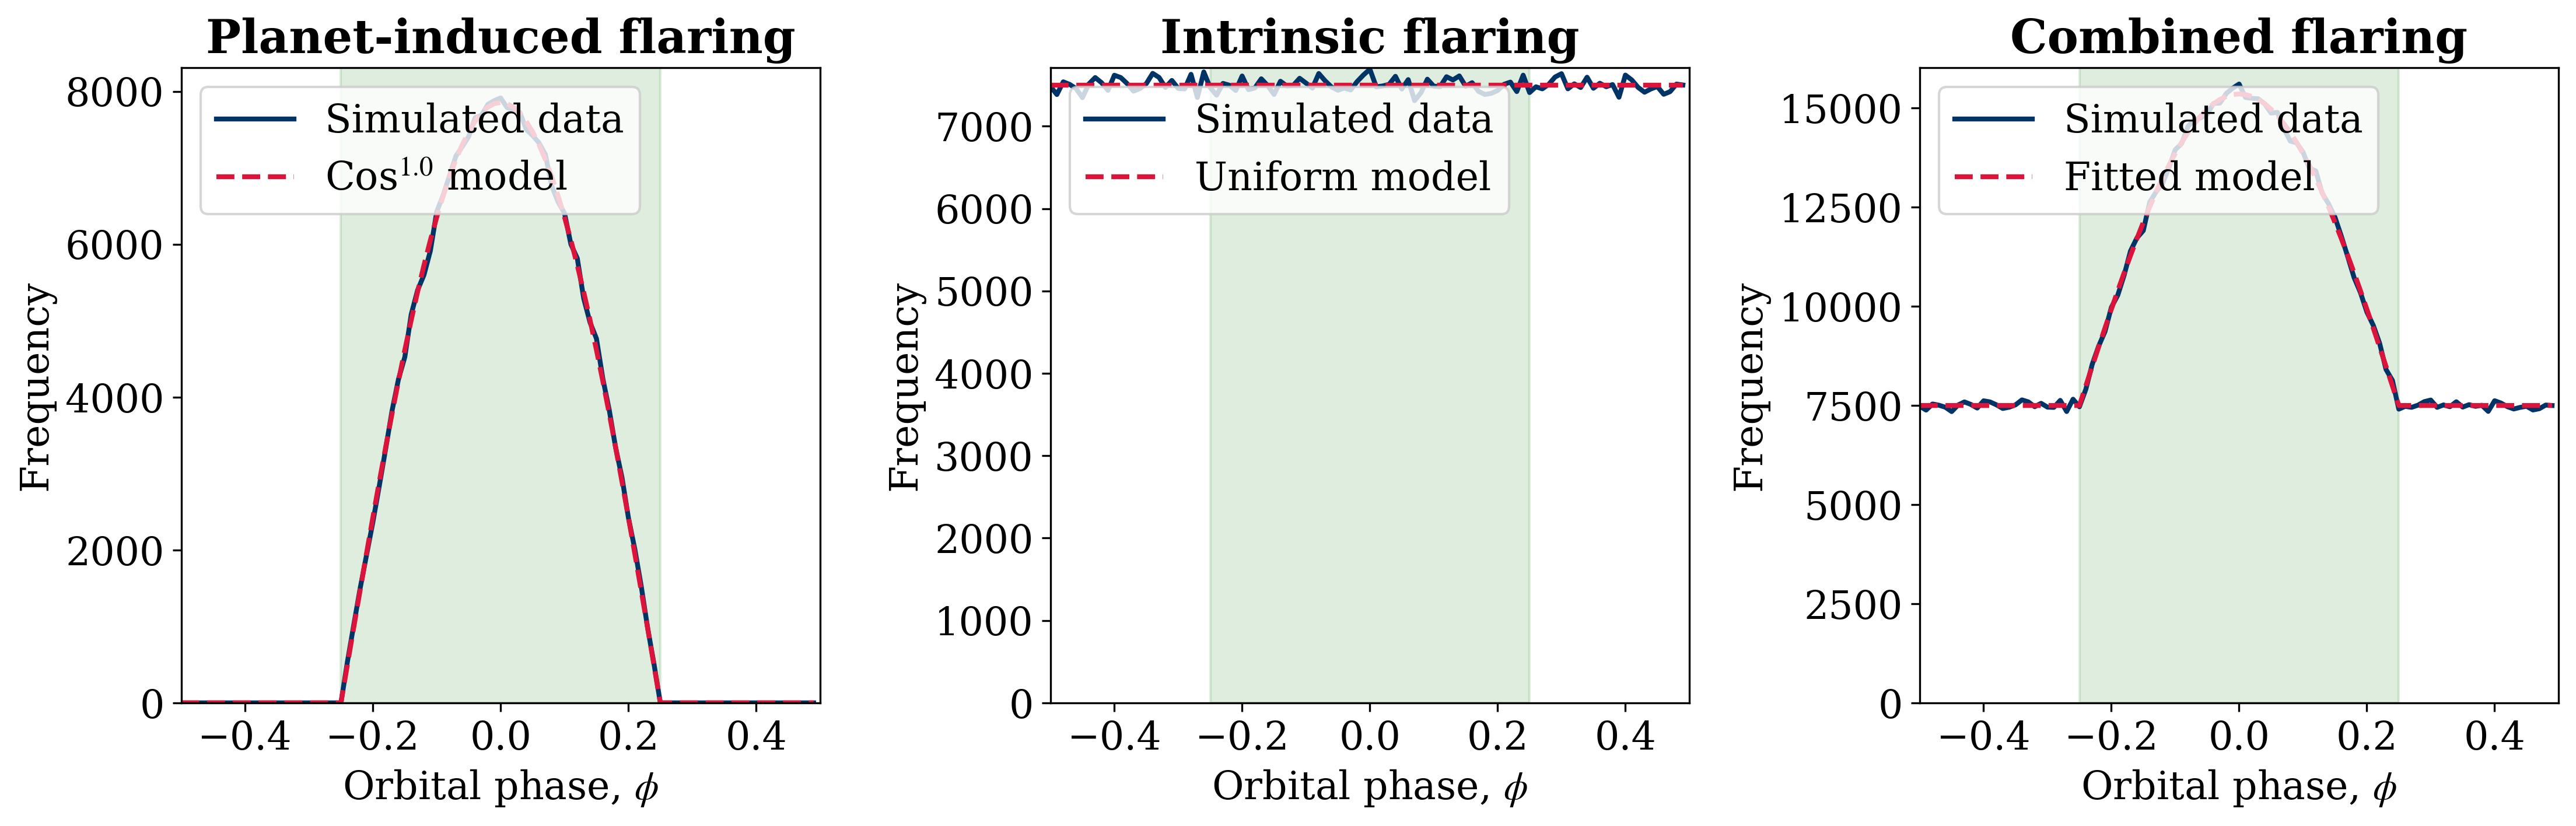

In [4]:
counts_planet, counts_intrinsic, counts, final_fit, normalized_final_fit = create_pdf(
    intrinsic_flaring_rate,
    planet_ratio,
    amount_of_flares,
    slope,
    E_thres,
    e_min,
    e_max,
    plot=True
)


## Sanity check: does the model recover the requested PIP?

This is the main check that was missing before.  
Because the SPI region covers half of the phase space, the expected planet-induced percentage is

\[
\mathrm{PIP} = P_{\rm in} - P_{\rm out}.
\]

For the corrected model, this should reproduce the input PIP.


In [5]:
ratios = [0.00, 0.05, 0.25, 0.50, 0.75, 0.95, 1.00]

rows = []
for ratio in ratios:
    model = flare_distribution_model(
        intrinsic_flaring_rate=intrinsic_flaring_rate,
        planet_ratio=ratio,
        slope=slope,
        n_bins=100
    )

    recovered_pip, p_in, p_out = estimate_pip_from_distribution(
        model["p_total"],
        model["phase"]
    )

    rows.append({
        "Input PIP": ratio,
        "P_in": p_in,
        "P_out": p_out,
        "Recovered PIP = P_in - P_out": recovered_pip,
    })

sanity_df = pd.DataFrame(rows)
sanity_df


,Input PIP,P_in,P_out,Recovered PIP = P_in - P_out
0,0.00,0.500,0.500,0.00
1,0.05,0.525,0.475,0.05
2,0.25,0.625,0.375,0.25
3,0.50,0.750,0.250,0.50
4,0.75,0.875,0.125,0.75
5,0.95,0.975,0.025,0.95
6,1.00,1.000,0.000,1.00


## Comparing several PIP values

The curves below use the same plot style as the original notebook.  
The important correction is that they are normalised by a **single global maximum**, not by their own maximum. Otherwise a low-PIP model is forced to peak at 1 and can look much stronger than it actually is.


In [6]:
p = []
m = []
n = []

ratios = [0.05, 0.25, 0.50, 0.75, 0.95]

for ratio in ratios:
    counts_planet, counts_intrinsic, counts, final_fit, normalized_final_fit = create_pdf(
        0.5,
        ratio,
        amount_of_flares,
        slope,
        E_thres,
        e_min,
        e_max,
        plot=False
    )

    p.append(normalized_final_fit)
    m.append(counts)
    n.append(final_fit)


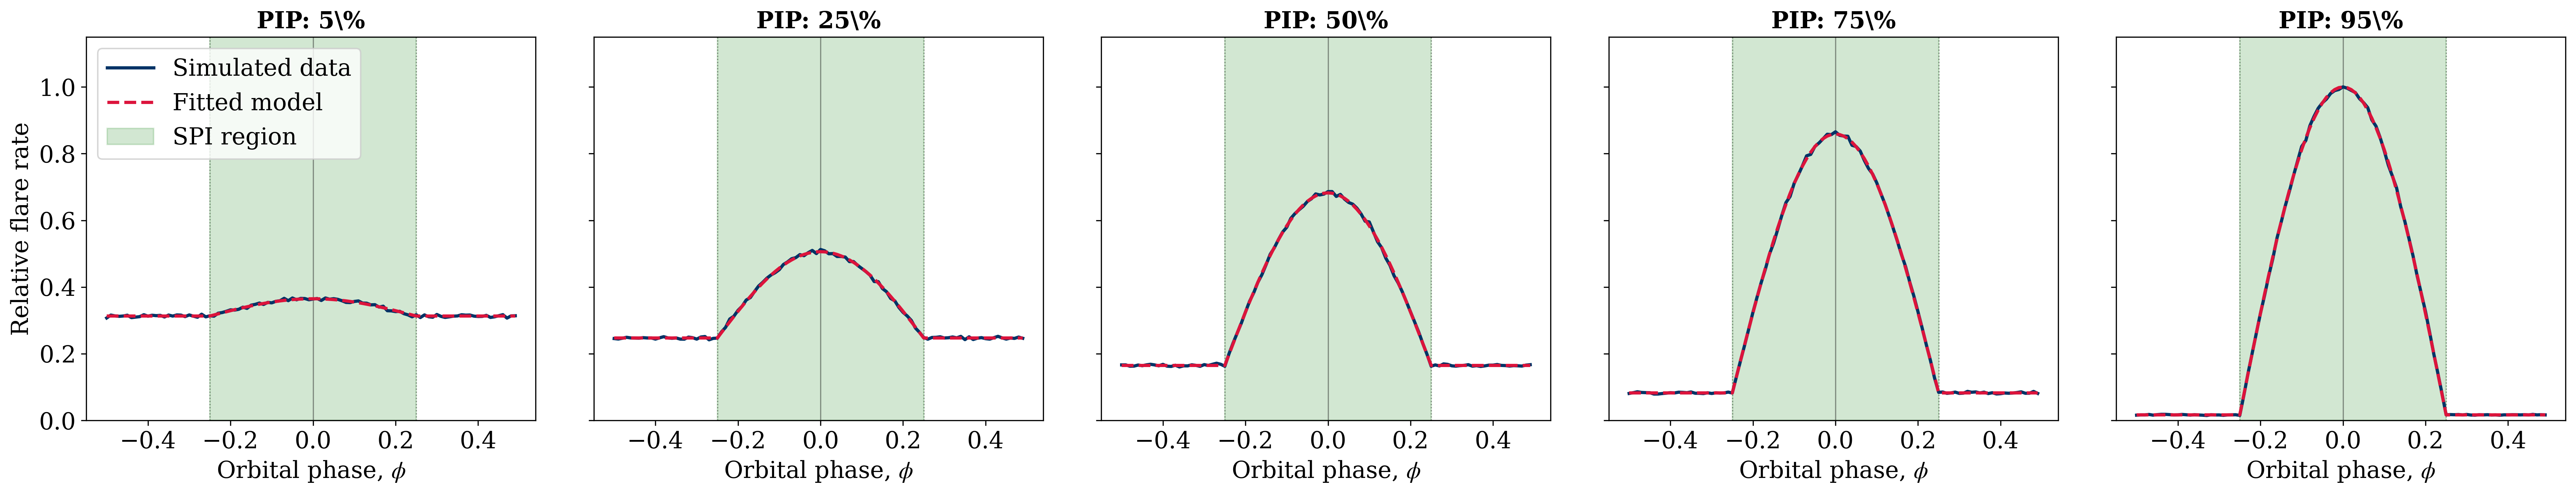

In [7]:
rows, cols = 1, 5

fig, ax = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5), sharey=True)
ax = np.atleast_1d(ax).flatten()

x = np.arange(-0.5, 0.5, 1 / 100)

# Use a global maximum so the relative amplitude between PIP values is preserved.
global_max = max(np.max(curve) for curve in n)

for i in range(len(p)):
    m_norm = m[i] / global_max
    n_norm = n[i] / global_max

    ax[i].plot(x, m_norm, color="#003366", lw=2.2, label="Simulated data", zorder=10)
    ax[i].plot(x, n_norm, color="crimson", lw=2.2, ls="--", label="Fitted model", zorder=10)

    ax[i].axvspan(-0.25, 0.25, color="forestgreen", label="SPI region", alpha=0.2, zorder=1)
    ax[i].axvline(0, color="black", lw=0.8, alpha=0.4, zorder=2)
    ax[i].axvline(-0.25, color="black", lw=0.8, ls=":", alpha=0.4, zorder=2)
    ax[i].axvline(0.25, color="black", lw=0.8, ls=":", alpha=0.4, zorder=2)

    ax[i].set_xlabel(r"Orbital phase, $\phi$")
    ax[i].set_ylim(0, 1.15)
    ax[i].set_title(rf"PIP: {ratios[i] * 100:.0f}\%", weight="bold", fontsize=16)

    if i == 0:
        ax[i].set_ylabel("Relative flare rate")
        ax[i].legend(loc="upper left")
    else:
        ax[i].tick_params(axis="y", labelleft=False)

plt.tight_layout()
plt.savefig("figures/flare_distribution_models_corrected.png", bbox_inches="tight", dpi=300)
plt.show()


## Single plot with the fitted models only

This version makes it easier to see the progression with PIP.  
The colour bar is fixed from 0 to 100%, so it always mentions both the minimum and maximum possible PIP values.


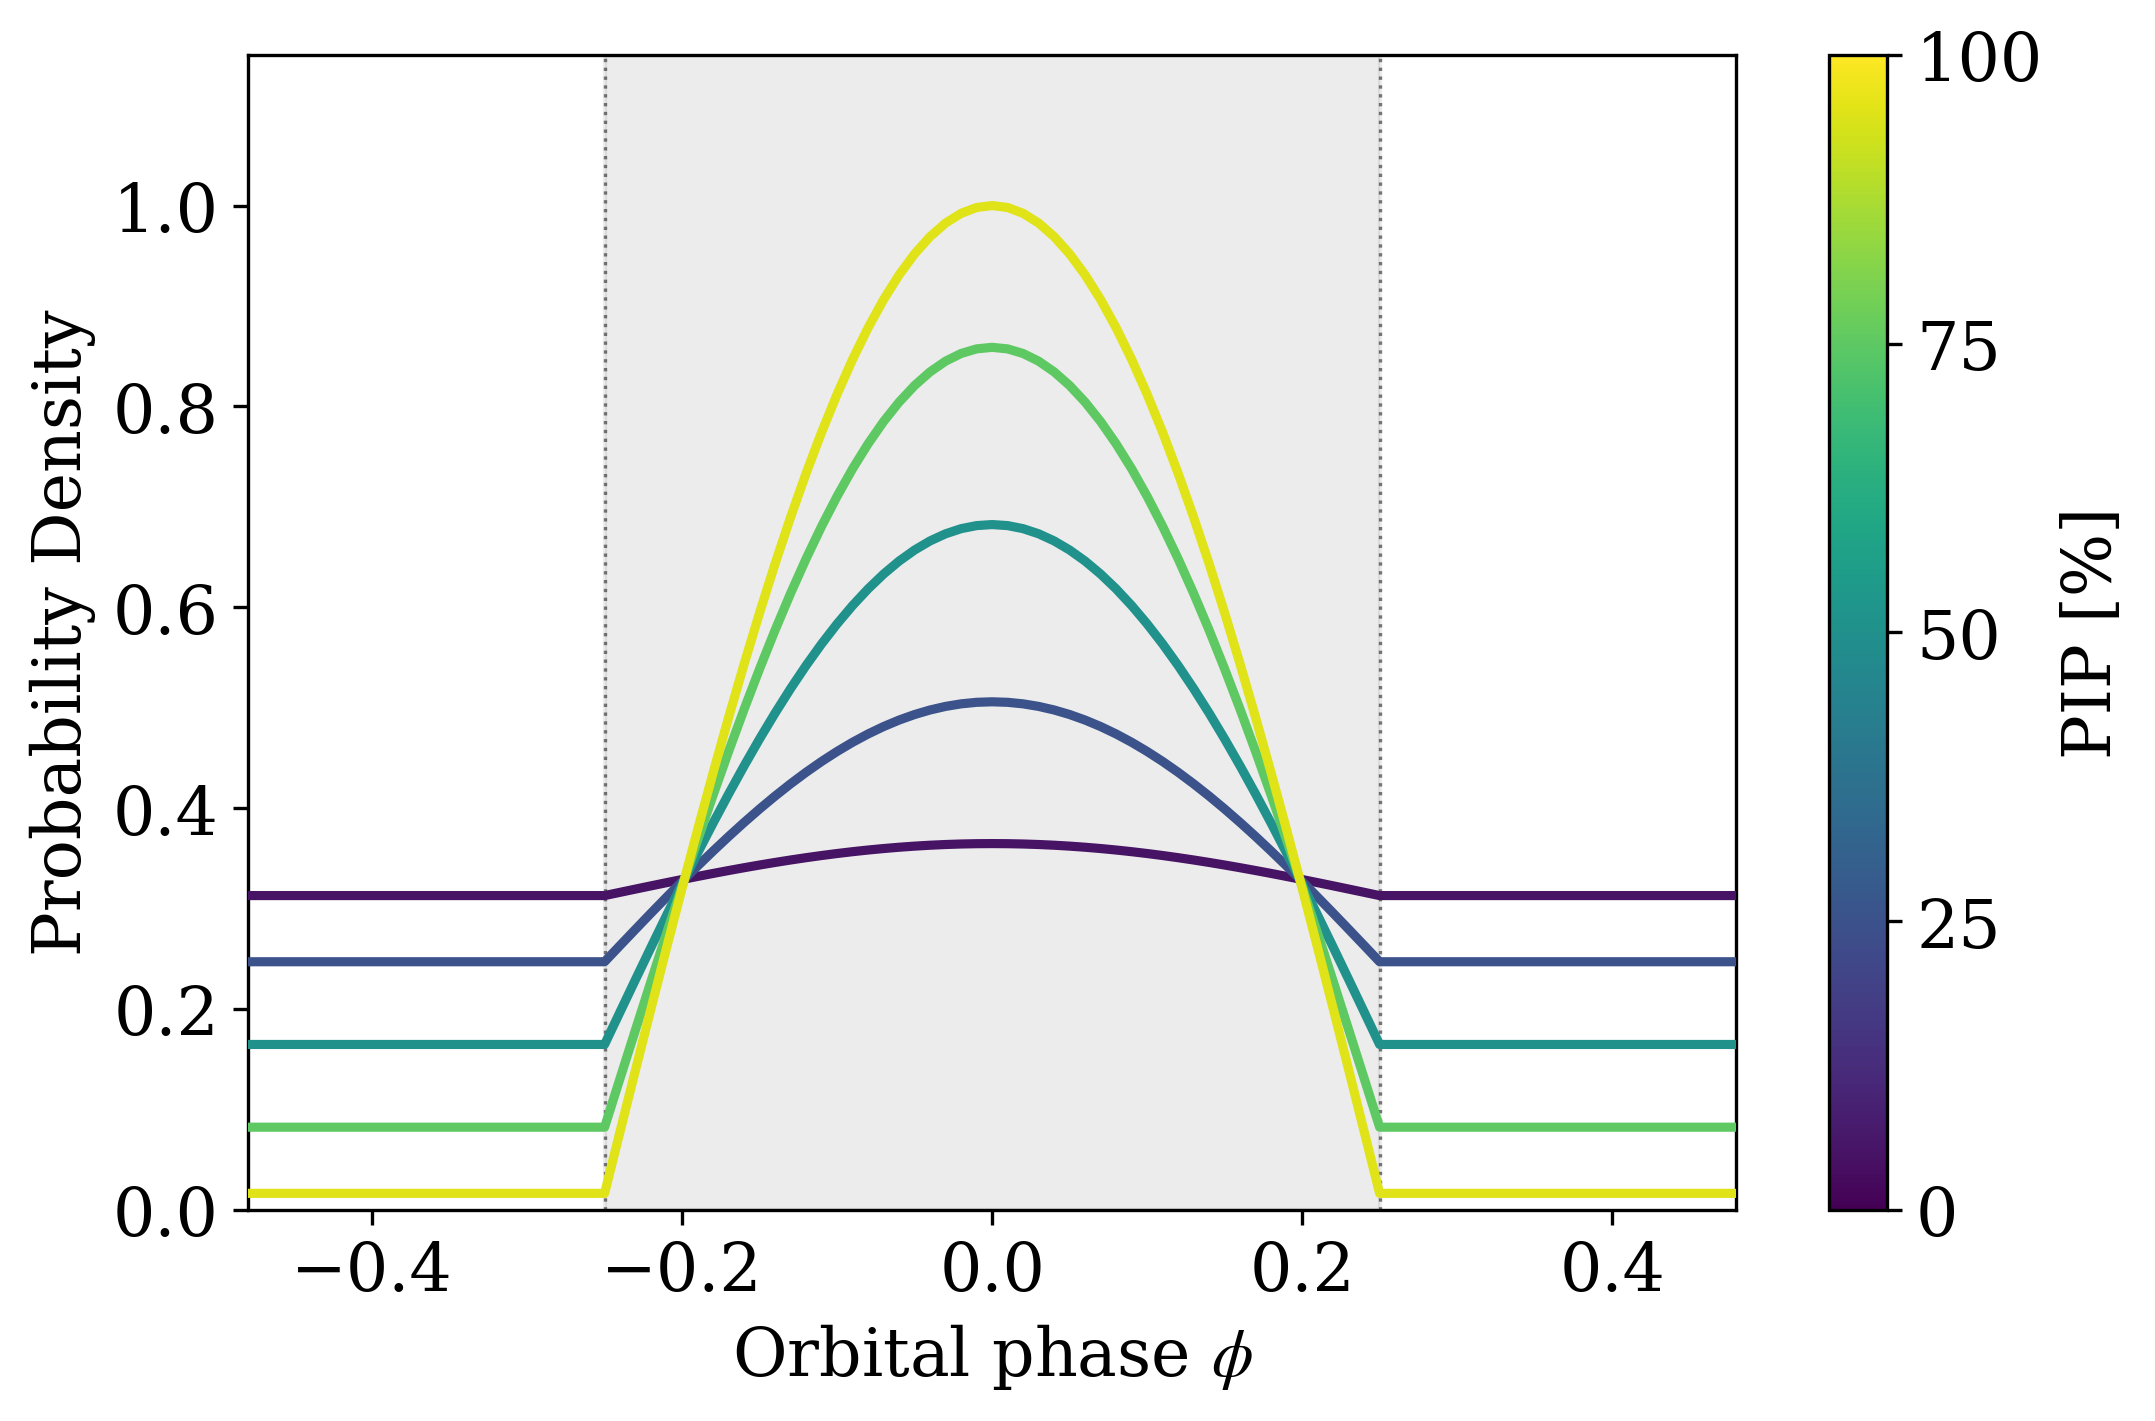

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(-0.5, 0.5, 1 / 100)

pip_percent = np.array(ratios) * 100
norm = Normalize(vmin=0, vmax=100)
cmap = plt.cm.viridis

# Mark the assumed SPI phase region.
ax.axvspan(
    -0.25, 0.25,
    color="grey",
    alpha=0.15,
    zorder=1,
    label="SPI region"
)

#ax.axvline(0, color="black", lw=1, alpha=0.5, zorder=2)
ax.axvline(-0.25, color="black", lw=0.8, ls=":", alpha=0.5, zorder=2)
ax.axvline(0.25, color="black", lw=0.8, ls=":", alpha=0.5, zorder=2)

global_max = max(np.max(curve) for curve in n)

for i in range(len(p)):
    n_norm = n[i] / global_max

    ax.plot(
        x,
        n_norm,
        color=cmap(norm(pip_percent[i])),
        lw=2.2,
        zorder=10
    )

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("PIP [%]")
cbar.set_ticks([0, 25, 50, 75, 100])

ax.set_xlabel(r"Orbital phase $\phi$")
ax.set_ylabel("Probability Density")
ax.set_xlim(-0.48, 0.48)
ax.set_ylim(0, 1.15)

plt.savefig("figures/flare_distribution_fits_viridis_corrected2.pdf", bbox_inches="tight", dpi=300)
plt.show()


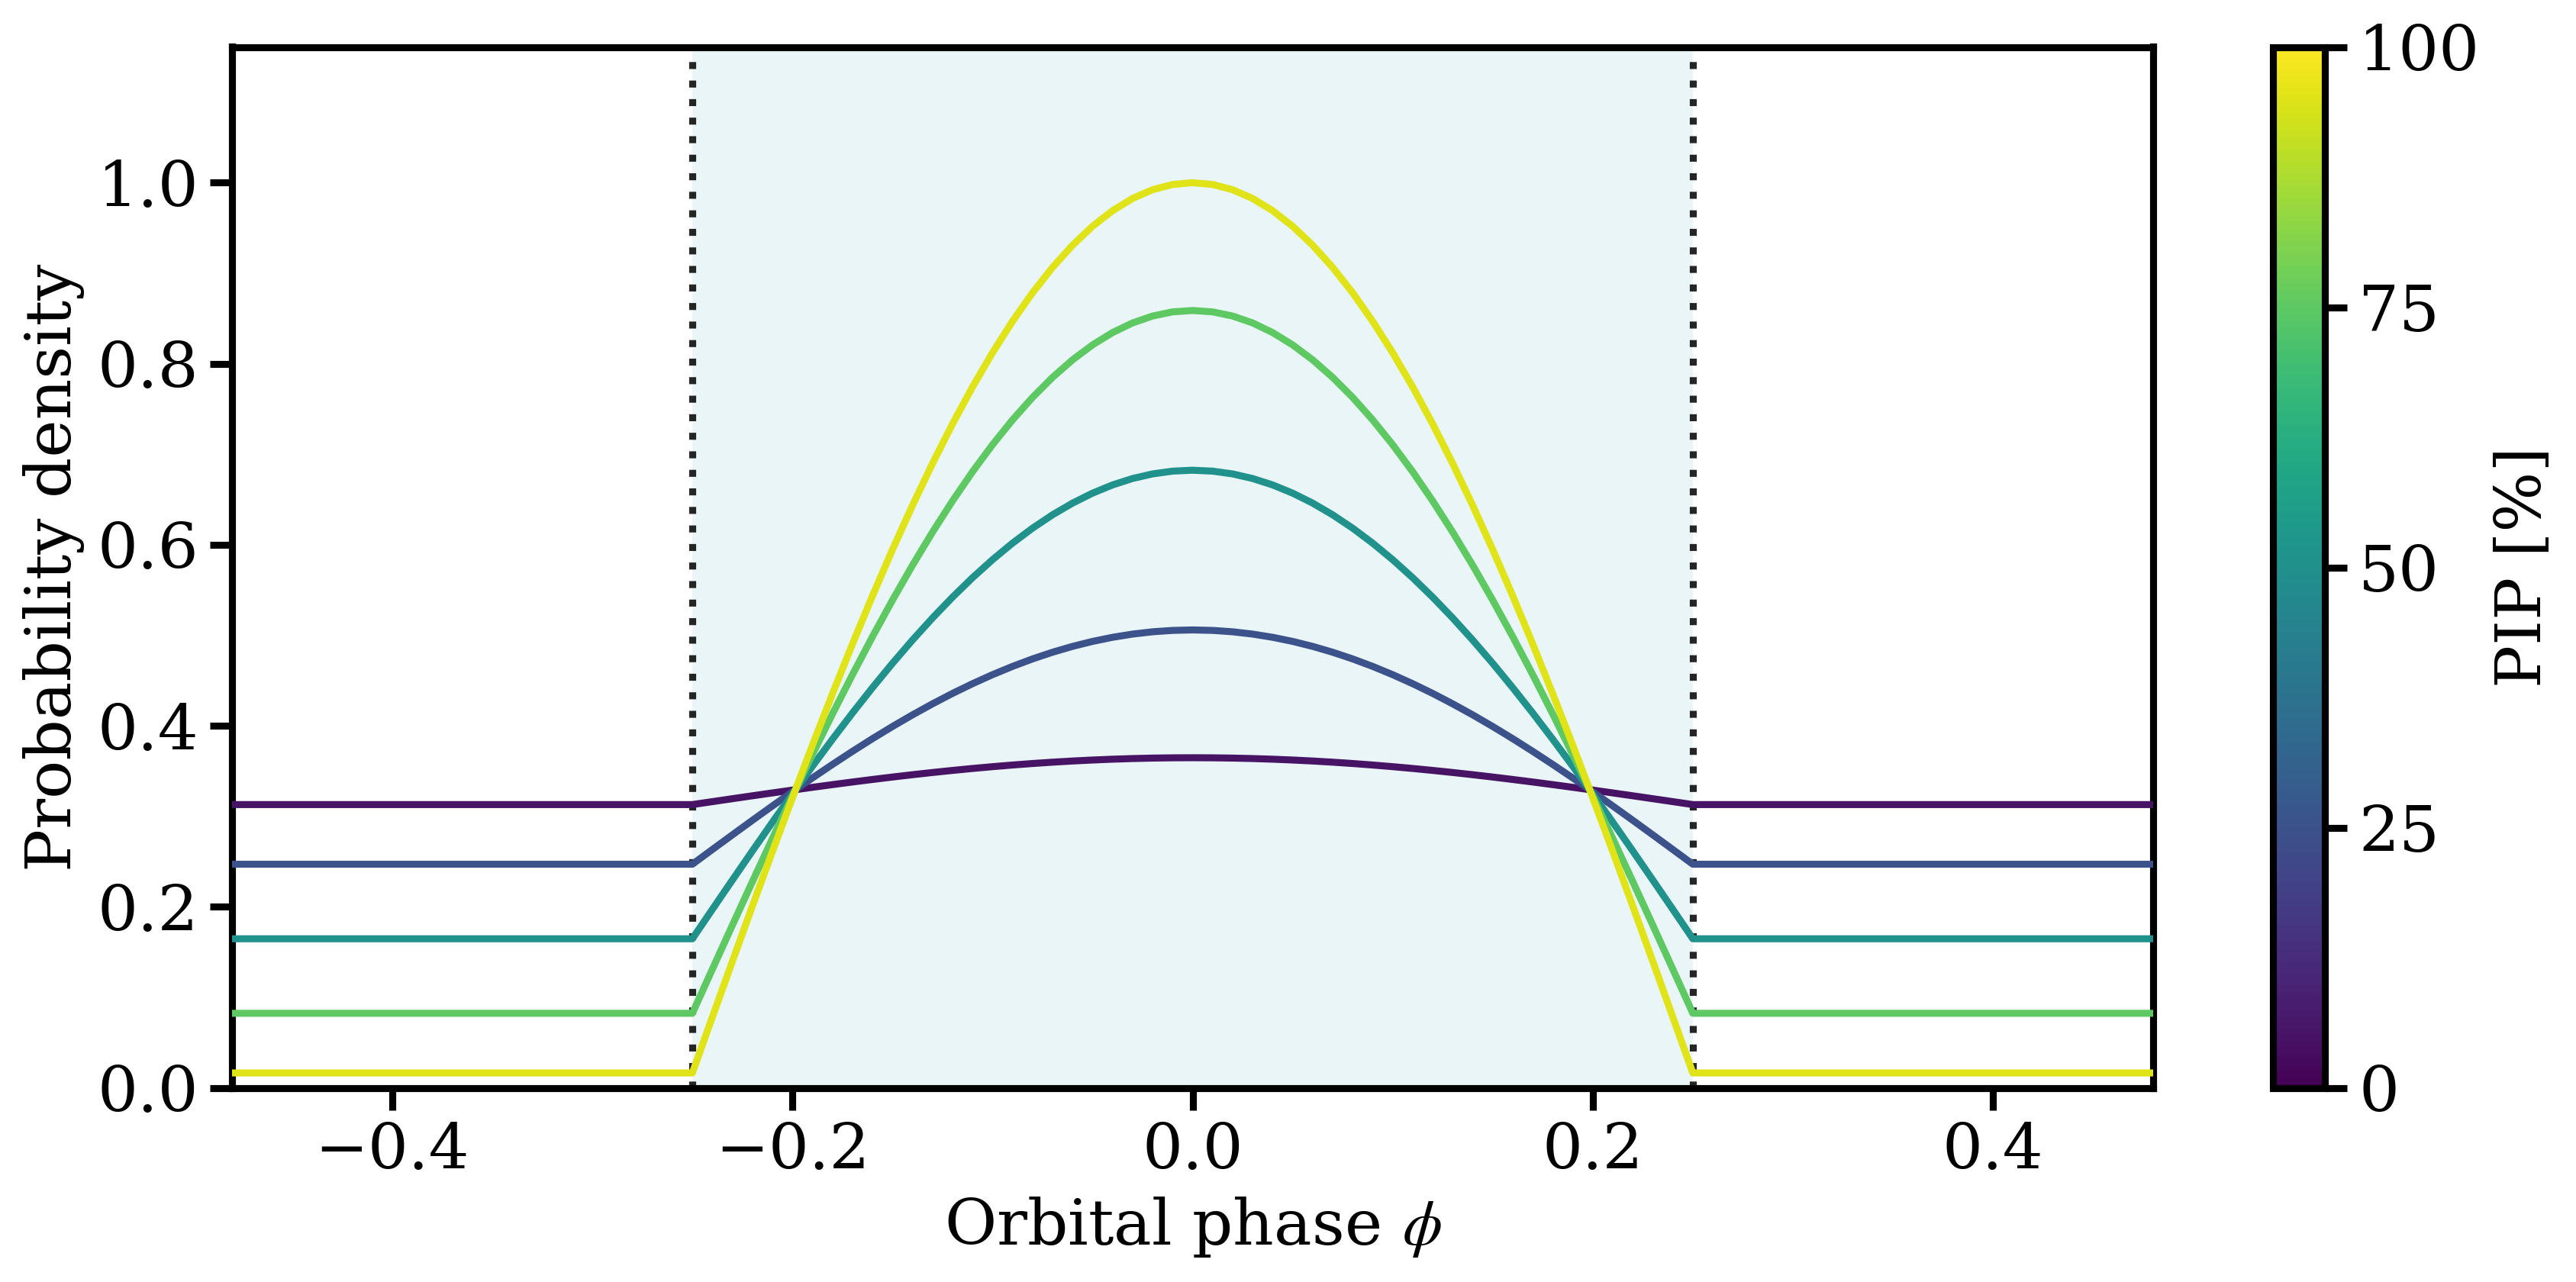

In [9]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import ScalarFormatter

# ------------------------------------------------------------
# Thesis-style constants
# ------------------------------------------------------------
FONTSIZE = 20
LINEWIDTH = 2.2

plt.rcParams.update({
    "font.size": FONTSIZE,
    "axes.labelsize": FONTSIZE,
    "xtick.labelsize": FONTSIZE,
    "ytick.labelsize": FONTSIZE,
    "axes.linewidth": LINEWIDTH,
})

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------
x = np.arange(-0.5, 0.5, 1 / 100)

pip_percent = np.array(ratios) * 100
norm = Normalize(vmin=0, vmax=100)
cmap = plt.cm.viridis

global_max = max(np.max(curve) for curve in n)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# Mark the assumed SPI phase region
ax.axvspan(
    -0.25,
    0.25,
    color="lightblue",
    alpha=0.25,
    linewidth=0,
    zorder=1
)

# Mark SPI-region boundaries
ax.axvline(
    -0.25,
    color="black",
    linewidth=LINEWIDTH,
    linestyle=":",
    alpha=0.85,
    zorder=2
)

ax.axvline(
    0.25,
    color="black",
    linewidth=LINEWIDTH,
    linestyle=":",
    alpha=0.85,
    zorder=2
)

# Plot normalized probability-density curves
for i in range(len(p)):
    n_norm = n[i] / global_max

    ax.plot(
        x,
        n_norm,
        color=cmap(norm(pip_percent[i])),
        linewidth=LINEWIDTH,
        zorder=10
    )

# Colorbar is kept because color encodes PIP
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("PIP [%]", fontsize=FONTSIZE)
cbar.set_ticks([0, 25, 50, 75, 100])
cbar.ax.tick_params(
    labelsize=FONTSIZE,
    width=LINEWIDTH,
    length=7
)
cbar.outline.set_linewidth(LINEWIDTH)

# Axis labels and limits
ax.set_xlabel(r"Orbital phase $\phi$")
ax.set_ylabel("Probability density")

ax.set_xlim(-0.48, 0.48)
ax.set_ylim(0, 1.15)

# Disable scientific/offset notation
x_formatter = ScalarFormatter(useOffset=False)
x_formatter.set_scientific(False)
ax.xaxis.set_major_formatter(x_formatter)

y_formatter = ScalarFormatter(useOffset=False)
y_formatter.set_scientific(False)
ax.yaxis.set_major_formatter(y_formatter)

ax.tick_params(
    axis="both",
    which="major",
    width=LINEWIDTH,
    length=7
)

ax.tick_params(
    axis="both",
    which="minor",
    width=LINEWIDTH * 0.8,
    length=4
)

fig.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
output_dir = Path("figures")
output_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    output_dir / "flare_distribution_fits_viridis_corrected.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Waiting-time plots

This keeps the same kind of waiting-time plot as the original notebook, but now the fake flare times are drawn from the corrected phase distribution.


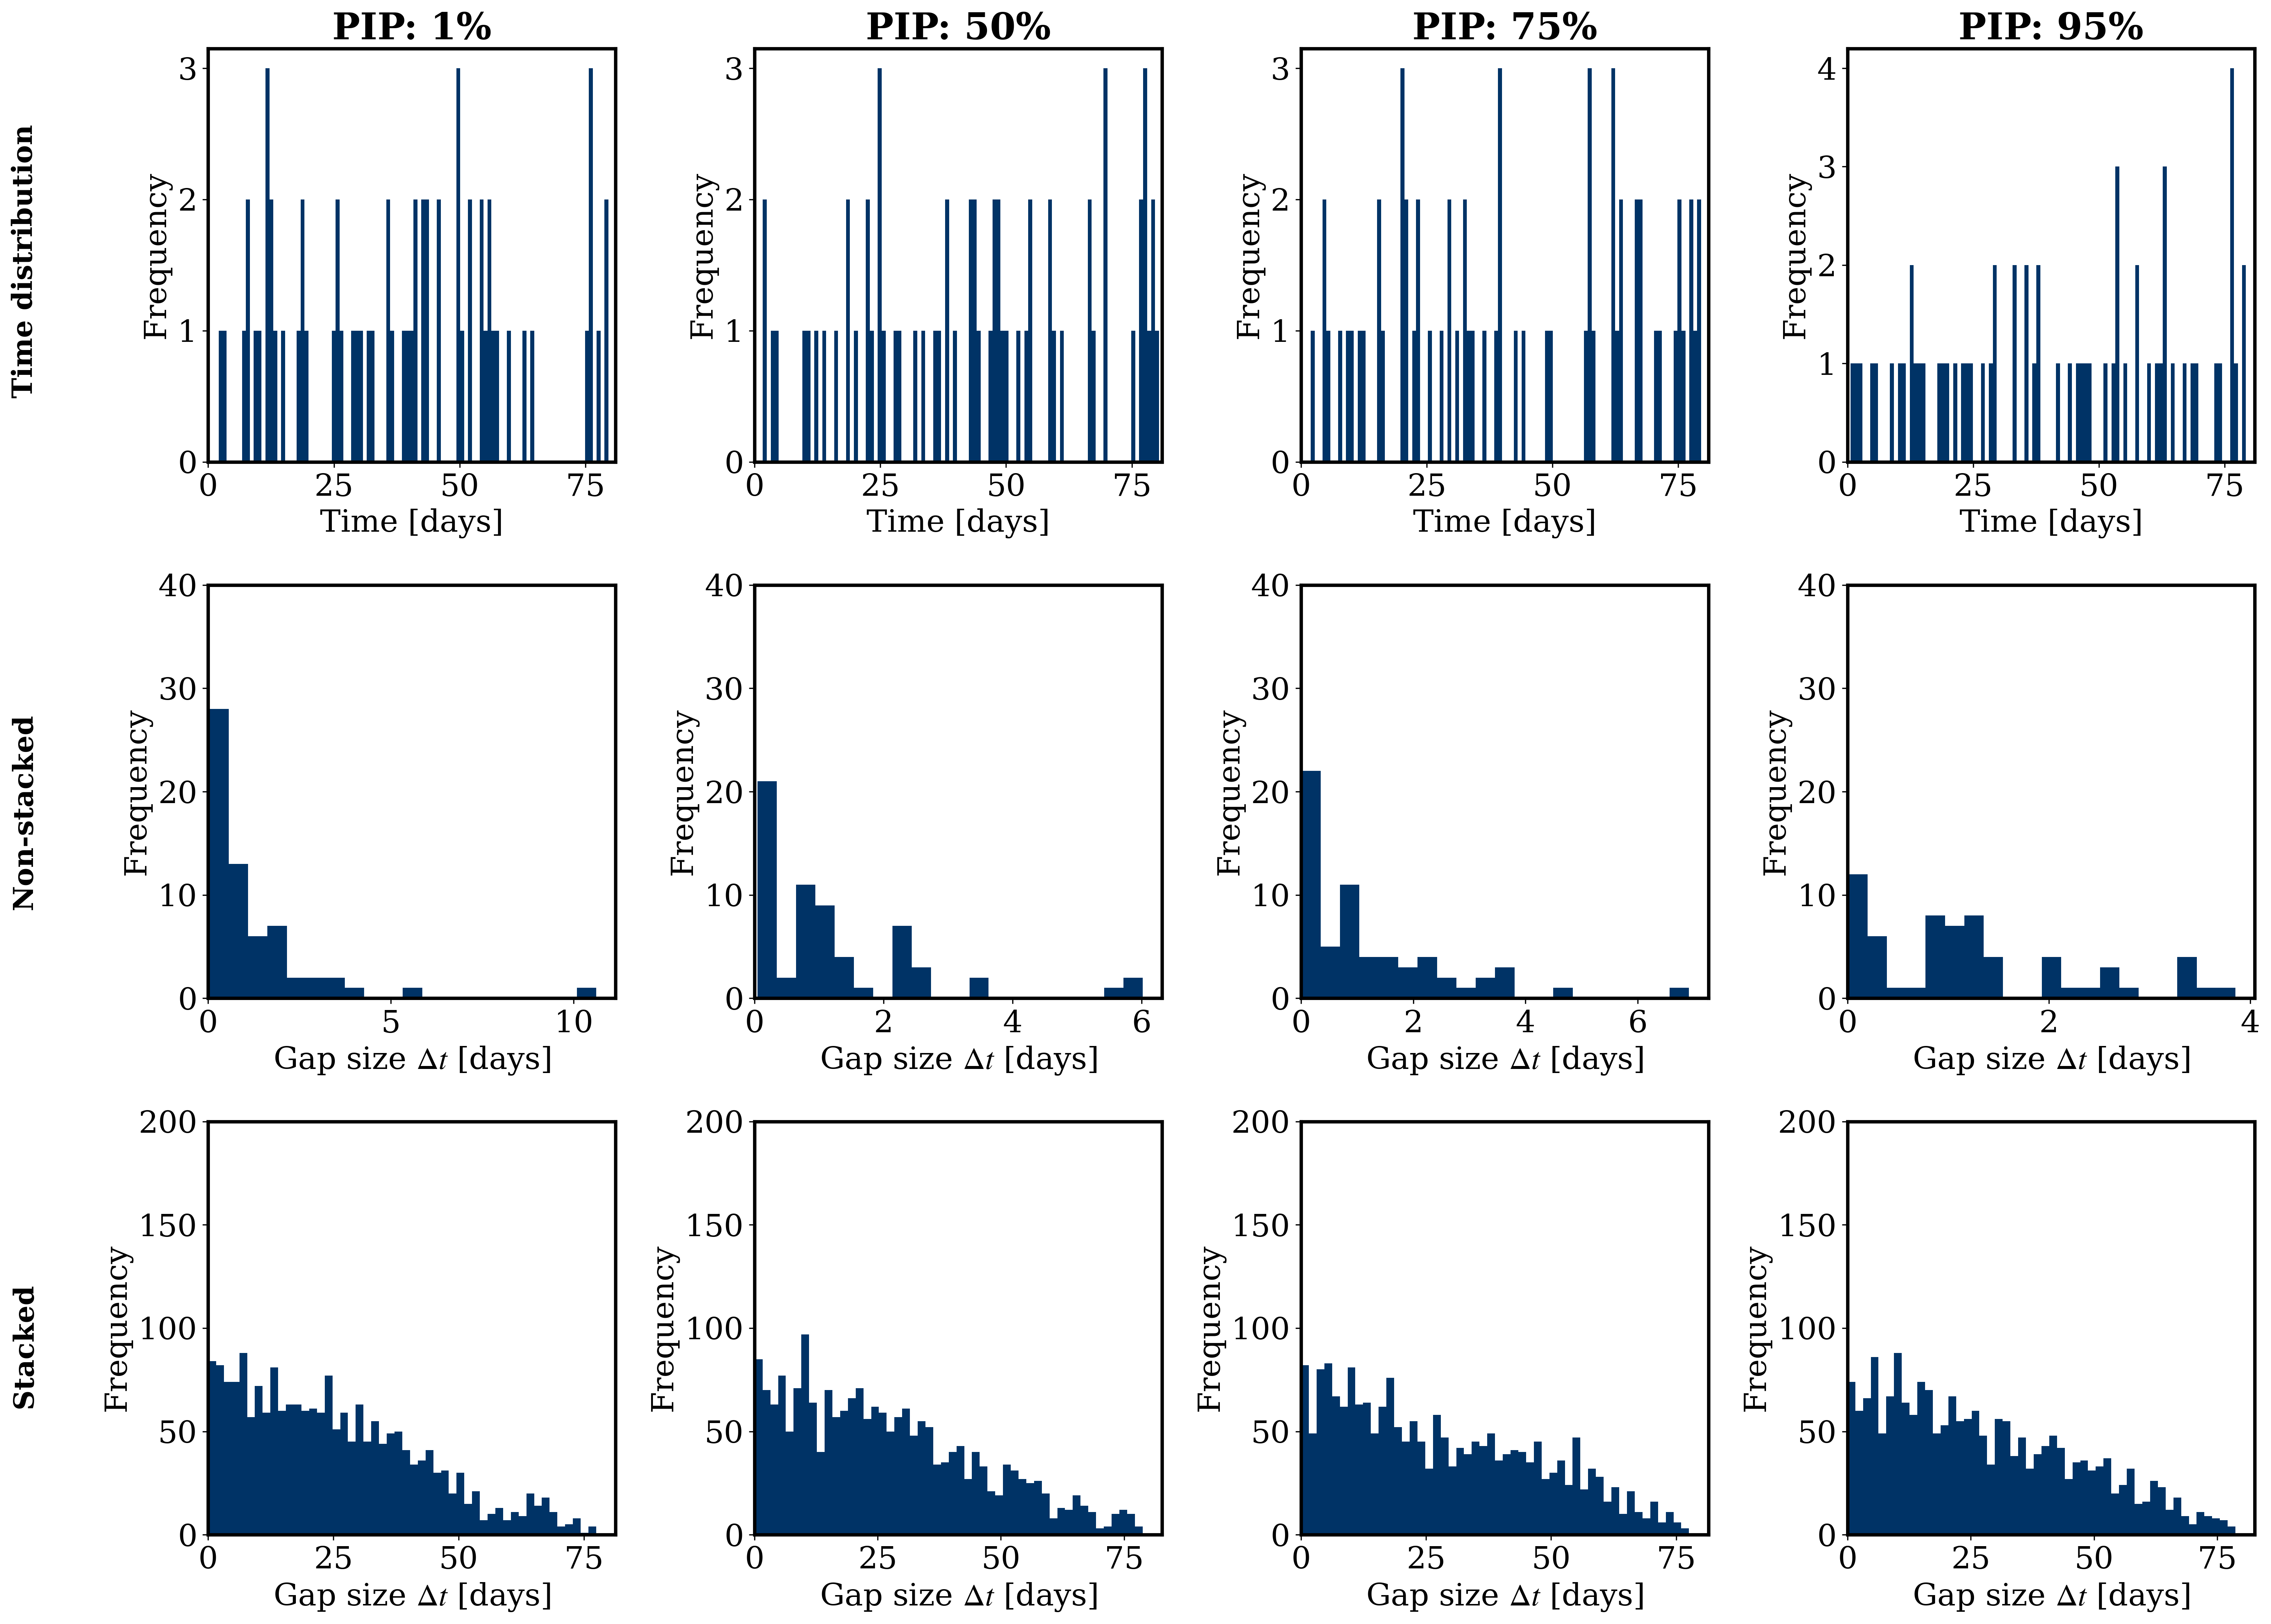

In [10]:
slope = -2
amount_of_flares = int(1e6)
intrinsic_flaring_rate = 0.8
planet_ratio_list = [0.01, 0.50, 0.75, 0.95]
total_observing_time = 81  # days
Period = 1.208             # days

fig, ax = plt.subplots(3, 4, figsize=(4 * 5, 15))

for i, ratio in enumerate(planet_ratio_list):
    flare_times = Fake_data(
        intrinsic_flaring_rate,
        ratio,
        amount_of_flares,
        slope,
        E_thres,
        e_min,
        e_max,
        total_observing_time,
        Period,
        plot=False
    )

    diff = np.diff(np.sort(flare_times))
    diff2 = pairwise_waiting_times(np.sort(flare_times))

    ax[0, i].hist(flare_times, bins=100, color="#003366")
    ax[0, i].set_ylabel("Frequency")
    ax[0, i].set_xlabel("Time [days]")
    ax[0, i].set_title(f"PIP: {ratio * 100:.0f}%", weight="bold")
    ax[0, i].set_xlim(0, total_observing_time)

    ax[1, i].hist(diff, bins=20, color="#003366")
    ax[1, i].set_ylabel("Frequency")
    ax[1, i].set_xlabel(r"Gap size $\Delta t$ [days]")
    ax[1, i].set_xlim(0)
    ax[1, i].set_ylim(0, 40)

    ax[2, i].hist(diff2, bins=50, color="#003366")
    ax[2, i].set_ylabel("Frequency")
    ax[2, i].set_xlabel(r"Gap size $\Delta t$ [days]")
    ax[2, i].set_xlim(0)
    ax[2, i].set_ylim(0, 200)

fig.text(-0.02, 0.83, "Time distribution", ha="center", va="center",
         rotation="vertical", fontsize=18, weight="bold")
fig.text(-0.02, 0.50, "Non-stacked", ha="center", va="center",
         rotation="vertical", fontsize=18, weight="bold")
fig.text(-0.02, 0.18, "Stacked", ha="center", va="center",
         rotation="vertical", fontsize=18, weight="bold")

plt.tight_layout()
plt.savefig("figures/waiting_time_examples_corrected.png", bbox_inches="tight", dpi=300)
plt.show()


## Picking flares from the corrected model

This keeps the same type of sampling plot as the original notebook.


ValueError: x and y must have same first dimension, but have shapes (50,) and (100,)

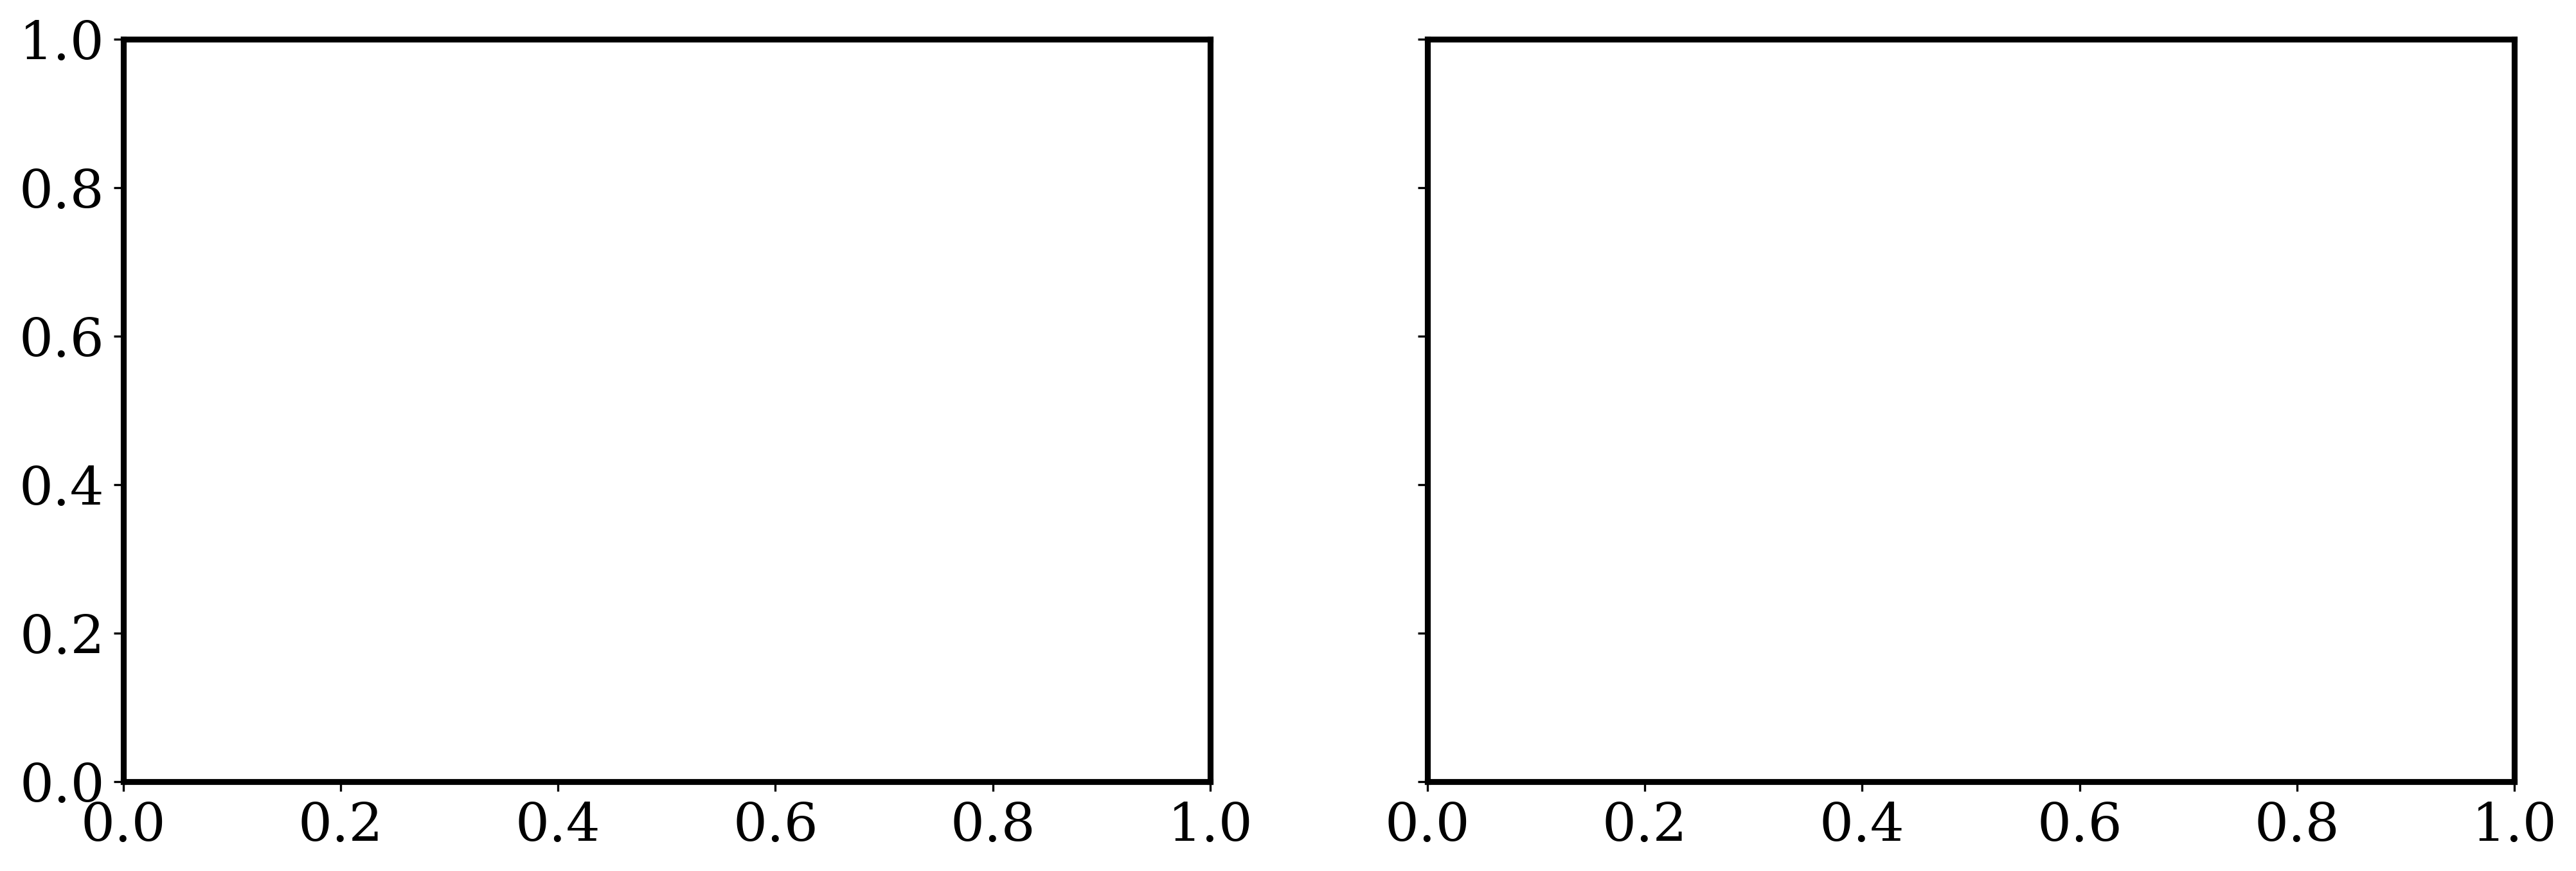

In [11]:
planet_induced_ratios = [0.20, 0.30]
amount_of_flares = int(1e6)
T_baseline = 500
intrinsic_flare_rate = 0.2
slope = -2
E_thres = 2
e_min = 0.1
e_max = 1e8

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

x = np.arange(-0.5, 0.5, 1 / 50)

for i, ratio in enumerate(planet_induced_ratios):
    counts_planet, counts_intrinsic, counts, final_fit, normalized_final_fit = create_pdf(
        intrinsic_flare_rate,
        ratio,
        amount_of_flares,
        slope,
        E_thres,
        e_min,
        e_max,
        plot=False
    )

    axes[i].plot(x, final_fit / final_fit.sum(), color="#003366", lw=2, zorder=10)
    axes[i].set_title(f"PIP = {ratio * 100:.0f}%", weight="bold")
    axes[i].set_xlabel(r"Orbital phase, $\phi$")

    if i == 0:
        axes[i].set_ylabel("Probability per phase bin")

    axes[i].axvspan(-0.25, 0.25, color="forestgreen", alpha=0.15, zorder=1,
                    label="SPI region" if i == 0 else None)
    axes[i].axvline(-0.25, color="forestgreen", alpha=0.5, zorder=1)
    axes[i].axvline(0.25, color="forestgreen", alpha=0.5, zorder=1)

axes[0].legend(loc="upper left")

fig.tight_layout()
fig.savefig("figures/PDF_for_various_PIP_corrected.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for i, ratio in enumerate(planet_induced_ratios):
    counts_planet, counts_intrinsic, counts, final_fit, normalized_final_fit = create_pdf(
        intrinsic_flare_rate,
        ratio,
        amount_of_flares,
        slope,
        E_thres,
        e_min,
        e_max,
        plot=False
    )

    points = sample_points(x, normalized_final_fit, 50)

    axes[i].hist(points, bins=50, color="#003366", zorder=10,
                 alpha=0.8, edgecolor="black")

    if i == 0:
        axes[i].set_ylabel("Frequency")

    axes[i].axvspan(-0.25, 0.25, color="forestgreen", alpha=0.15, zorder=1,
                    label="SPI region" if i == 0 else None)
    axes[i].axvline(-0.25, color="forestgreen", alpha=0.5, zorder=1)
    axes[i].axvline(0.25, color="forestgreen", alpha=0.5, zorder=1)

    axes[i].set_title(f"PIP = {ratio * 100:.0f}%", weight="bold")
    axes[i].set_xlabel(r"Orbital phase, $\phi$")

axes[0].legend(loc="upper left")

fig.tight_layout()
fig.savefig("figures/Picking_Flares_corrected.png", dpi=300, bbox_inches="tight")
plt.show()


## Final simple histogram check

In [ ]:
# Simple check for one model.
counts_planet, counts_intrinsic, counts, final_fit, normalized_final_fit = create_pdf(
    0.24,
    0.95,
    int(1e6),
    slope,
    E_thres,
    e_min,
    e_max,
    plot=False
)

points = sample_points(x, normalized_final_fit, 23)

fig, ax1 = plt.subplots(figsize=(7, 4))

ax1.plot(x, normalized_final_fit, color="crimson", lw=2)
ax1.set_ylabel("Model probability per bin", color="crimson")
ax1.tick_params(axis="y", labelcolor="crimson")

ax2 = ax1.twinx()
ax2.hist(points, bins=30, color="#003366", alpha=0.8)
ax2.set_ylabel("Sampled flare count", color="#003366")
ax2.tick_params(axis="y", labelcolor="#003366")

ax1.set_xlabel(r"Orbital phase, $\phi$")
ax1.set_title("Sampling check", weight="bold")

plt.tight_layout()
plt.savefig("figures/sampling_check_corrected.png", bbox_inches="tight", dpi=300)
plt.show()


## Optional export cells

The original notebook contained several long export loops.  
I kept them commented out here, because they can create many files and take a long time to run.


In [25]:
pir = 0.999
periods = np.arange(0.5,8.1,0.01)
T_baseline = 100
n_flares = 10
ifr = n_flares / T_baseline

for random_period in periods:
    flare_times = Fake_data_RT(
        ifr,
        pir,
        amount_of_flares,
        slope,
        E_thres,
        e_min,
        e_max,
        T_baseline,
        random_period,
        plot=False
    )
    
    out_dir = f"../Data/Harmonic-test/50percent"
    os.makedirs(out_dir, exist_ok=True)
    
    df = pd.DataFrame({"tstart": flare_times})
    df["true_period"] = round(random_period,1)
    df["T_baseline"] = T_baseline
    df["planet_induced_ratio"] = pir
    
    df.to_csv(f"{out_dir}/{random_period:.2f}_flares.csv", index=False)


In [22]:
df

,tstart,true_period,T_baseline,planet_induced_ratio
0,2.684635,8.0,100,0.999
1,3.683747,8.0,100,0.999
2,5.699614,8.0,100,0.999
3,10.623845,8.0,100,0.999
4,11.853905,8.0,100,0.999
5,11.933169,8.0,100,0.999
6,12.107287,8.0,100,0.999
7,12.379807,8.0,100,0.999
8,13.440217,8.0,100,0.999
9,18.856950,8.0,100,0.999


In [31]:
import os
import numpy as np
import pandas as pd

slope = -2
amount_of_flares = int(1e6)

all_flares_list = []
n_flares_list = []
skipped_rows = []

combined_summary = pd.read_csv("../Data/Selas-TIC-ids/combined_summary.csv")

for i in range(len(combined_summary)):
    row = combined_summary.iloc[i]

    TIC_id = row['TIC_id']

    n_flares_raw = row['n_flares']
    pip_raw = row['planet_induced_percentage']
    time_span_days = row['time_span_days']
    net_observing_time_days = row['net_observing_time_days']
    period = row['RT_best_period']

    # Skip invalid rows
    if (
        pd.isna(n_flares_raw) or n_flares_raw == 0 or
        pd.isna(pip_raw) or
        pd.isna(time_span_days) or time_span_days <= 0 or
        pd.isna(net_observing_time_days) or net_observing_time_days <= 0 or
        pd.isna(period) or period <= 0
    ):
        skipped_rows.append(TIC_id)
        continue

    eta = time_span_days / net_observing_time_days
    n_flares = int(round(n_flares_raw * eta, 0))

    # Skip if eta-corrected flare count becomes 0
    if n_flares == 0:
        skipped_rows.append(TIC_id)
        continue

    PIP = pip_raw / 100

    # Skip if PIP is outside the valid range for Fake_data
    if pd.isna(PIP) or PIP < 0 or PIP > 1:
        skipped_rows.append(TIC_id)
        continue

    out_dir = f"../Data/eta_1_simulations/{TIC_id}/"
    os.makedirs(out_dir, exist_ok=True)

    n_flares_list.append(n_flares_raw)
    all_flares_list.append(n_flares)

    total_observation_time = time_span_days
    intrinsic_flaring_rate = n_flares / total_observation_time

    print(TIC_id, PIP)

    flare_times = Fake_data(
        intrinsic_flaring_rate,
        PIP,
        n_flares,
        slope,
        E_thres,
        e_min,
        e_max,
        total_observation_time,
        period,
        plot=False
    )

    output_path = f"../Data/eta_1_simulations/{TIC_id}/{TIC_id}_flares.csv"

    pd.DataFrame({"flare_time": flare_times}).to_csv(output_path, index=False)

print(f"Skipped {len(skipped_rows)} rows")

737327 1.0
7491381 0.47752808988764045
7586485 0.6111111111111112
11046349 0.6785714285714286
12359032 0.6590909090909091
13955147 0.5227272727272727
15444490 0.5945945945945946
15525212 0.8333333333333335
20096356 0.4798387096774194
20891744 0.8333333333333335
21168851 0.875
21434829 0.3684210526315789
21540586 0.75
21827610 0.5932203389830508
26076428 0.5
29939923 0.85
30946742 0.6052631578947368
30946945 0.7
32874669 0.40625
32930236 0.4130434782608695
36828969 1.0
38402758 0.5625
38827910 0.37460815047021945
43472154 0.48529411764705893
44797824 0.6785714285714286
46386531 0.42045454545454547
47425894 0.7
47428257 0.671875
50345701 0.6129032258064516
52588257 0.5238095238095238
53369126 0.5714285714285714
53417036 0.5714285714285714
56649881 0.6666666666666665
65416676 1.0
66944319 0.5714285714285714
67822383 0.9166666666666665
70742059 1.0
72445399 0.5285714285714286
76652075 0.9166666666666665
77371445 0.3467741935483871
78055898 0.5609756097560976
79358659 0.5657894736842105
794